<a href="https://colab.research.google.com/github/Tejaswimadastu/Machine_Learning/blob/main/Polynomial_Regression_Car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from sklearn.linear_model import LinearRegression
import pandas as pd

df = pd.read_csv('CarPrice_Assignment.csv')

X = df.select_dtypes(include=['int64','float64']).drop('price', axis=1)
y = df['price']

lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(df.head())


   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [7]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

print("✅ Models Trained Successfully!")

✅ Models Trained Successfully!


In [10]:
X_engine = df[['enginesize']]
y = df['price']


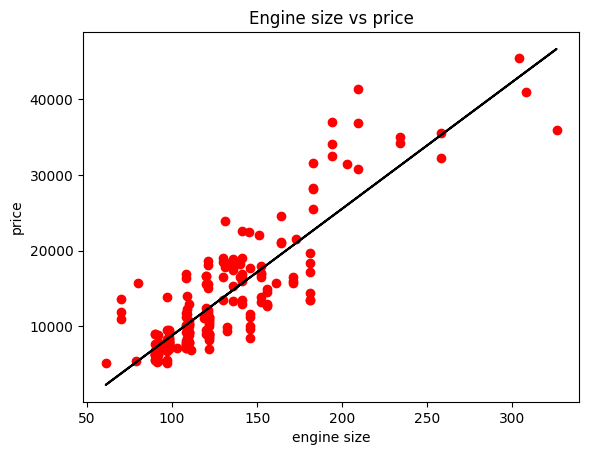

In [28]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

model = LinearRegression()
model.fit(X_engine, y)

plt.scatter(X_engine, y, color='red')
plt.plot(X_engine, model.predict(X_engine), color='black')

plt.title('Engine size vs price')
plt.xlabel('engine size')
plt.ylabel('price')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


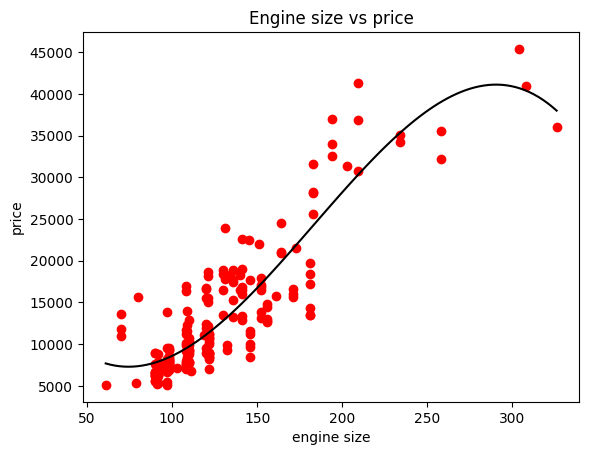

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X_engine)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# create smooth range
X_range = np.linspace(X_engine.min(), X_engine.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)

# plot
plt.scatter(X_engine, y, color='red')
plt.plot(X_range, poly_model.predict(X_range_poly), color='black')

plt.title('Engine size vs price')
plt.xlabel('engine size')
plt.ylabel('price')
plt.show()


In [25]:
X_engine = df[['enginesize']]
y = df['price']

lin_model = LinearRegression()
lin_model.fit(X_engine, y)

lin_model.predict([[6.5]])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-6915.40582459])

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Use polynomial-transformed X
y_pred = model.predict(X_poly)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Squared Error (MSE): 13091408.850448111
Mean Absolute Error (MAE): 2692.9296042010114
Root Mean Squared Error (RMSE): 3618.2051973938833
R² Score: 0.7938699575522645


In [27]:
# Polynomial Regression metrics (CORRECT)
y_poly_pred = poly_model.predict(poly.transform(X_engine))

mse_p = mean_squared_error(y, y_poly_pred)
mae_p = mean_absolute_error(y, y_poly_pred)
rmse_p = np.sqrt(mse_p)
r2_p = r2_score(y, y_poly_pred)

print("Polynomial MSE:", mse_p)
print("Polynomial MAE:", mae_p)
print("Polynomial RMSE:", rmse_p)
print("Polynomial R²:", r2_p)


Polynomial MSE: 13091408.850448111
Polynomial MAE: 2692.9296042010114
Polynomial RMSE: 3618.2051973938833
Polynomial R²: 0.7938699575522645
